# Comparison Delta Sigma Data Profiles
We will compare the difference when estimating the delta sigma profiles with different cosmologies to search for the galaxy sources around each cluster.
Here we only use one redshift bin (0.2, 0.8) and one richness bin (20, 200). 

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import h5py
from astropy.table import Table

import clmm
import clmm.cosmology.ccl


# ============================================================
# Paths
# ============================================================

BASE = "/sps/lsst/groups/clusters/cl_pipeline_project/TXPipe_data/cosmodc2"

cases = {
    "baseline": {
        "dir": f"{BASE}/outputs-full-2026",
        "Omega_c": 0.22,
        "sigma8": 0.80,
    },
    r"$\Omega_c=0.30$": {
        "dir": f"{BASE}/outputs-cosmo-03-09",
        "Omega_c": 0.30,
        "sigma8": 0.90,
    },
    r"$\Omega_c=0.40$": {
        "dir": f"{BASE}/outputs-cosmo-04-08",
        "Omega_c": 0.40,
        "sigma8": 0.80,
    },
}

In [2]:
# ============================================================
# Minimal helpers
# ============================================================

def make_cosmo(Omega_c, sigma8):
    cosmo = clmm.cosmology.ccl.CCLCosmology()
    cosmo.set_be_cosmo(
        clmm.cosmology.ccl.ccl.Cosmology(
            Omega_c=Omega_c,
            Omega_b=0.0448,
            h=0.71,
            sigma8=sigma8,
            n_s=0.963,
            Omega_k=0.0,
            w0=-1.0,
            wa=0.0,
        )
    )
    return cosmo


def read_clusters(cluster_tomo_path, zmin=0.2, zmax=0.8, lmin=20, lmax=200):
    rows = []

    with h5py.File(cluster_tomo_path, "r") as f:
        for key in f["cluster_bin"].keys():
            g = f["cluster_bin"][key]

            # assumes usual TXPipe cluster tomography datasets
            data = {name: g[name][:] for name in g.keys()}

            n = len(data["cluster_id"])
            for i in range(n):
                z = data["redshift"][i]
                rich = data["richness"][i]

                if (zmin <= z < zmax) and (lmin <= rich < lmax):
                    rows.append({
                        "id": int(data["cluster_id"][i]),
                        "ra": float(data["ra"][i]),
                        "dec": float(data["dec"][i]),
                        "redshift": float(z),
                        "richness": float(rich),
                    })

    return Table(rows)


def read_shear_catalog_index(cluster_shear_path):
    with h5py.File(cluster_shear_path, "r") as f:
        coord = f["provenance"].attrs["config/coordinate_system"]
        if isinstance(coord, bytes):
            coord = coord.decode()

        g = f["catalog"]
        ids = g["cluster_id"][:]
        starts = g["cluster_sample_start"][:]
        counts = g["cluster_sample_count"][:]

    return coord, {int(i): (int(s), int(c)) for i, s, c in zip(ids, starts, counts)}


def read_cluster_sources(cluster_shear_path, start, count):
    stop = start + count

    with h5py.File(cluster_shear_path, "r") as f:
        g = f["index"]

        tab = Table({
            "cluster_index": g["cluster_index"][start:stop],
            "cluster_id": g["cluster_id"][start:stop],
            "tangential_comp_clmm": g["tangential_comp"][start:stop],
            "cross_comp_clmm": g["cross_comp"][start:stop],
            "source_index": g["source_index"][start:stop],
            "weight_clmm": g["weight"][start:stop],
            "distance_arcmin": g["distance_arcmin"][start:stop],
        })

    return tab

In [3]:
# ============================================================
# Stack one big bin: 20 < lambda < 200, 0.2 < z < 0.8
# ============================================================

r_min = 1.1
r_max = 3.68
nbins = 7

distance_bins = clmm.dataops.make_bins(
    r_min,
    r_max,
    nbins=nbins,
    method="evenlog10width",
)

ensembles = {}

for label, cfg in cases.items():
    print("\n" + "=" * 80)
    print(label)

    cluster_tomo_path = f"{cfg['dir']}/cluster_catalog_tomography.hdf5"
    cluster_shear_path = f"{cfg['dir']}/cluster_shear_catalogs.hdf5"

    cosmo = make_cosmo(cfg["Omega_c"], cfg["sigma8"])

    clusters = read_clusters(
        cluster_tomo_path,
        zmin=0.2,
        zmax=0.8,
        lmin=20,
        lmax=200,
    )

    coord, shear_index = read_shear_catalog_index(cluster_shear_path)

    print("N clusters selected:", len(clusters))
    print("coordinate system:", coord)

    ensemble = clmm.ClusterEnsemble(label)

    for cl in clusters:
        cid = int(cl["id"])

        if cid not in shear_index:
            continue

        start, count = shear_index[cid]
        bg_cat = read_cluster_sources(cluster_shear_path, start, count)

        if len(bg_cat) == 0:
            continue

        galcat = clmm.GCData(bg_cat, meta={"coordinate_system": coord})
        galcat["theta"] = galcat["distance_arcmin"] * np.pi / (60.0 * 180.0)
        galcat["z"] = np.zeros(len(galcat))

        gc = clmm.GalaxyCluster(
            cid,
            cl["ra"],
            cl["dec"],
            cl["redshift"],
            galcat,
        )

        gc.richness = cl["richness"]

        gc.make_radial_profile(
            "mpc",
            bins=distance_bins,
            cosmo=cosmo,
            tan_component_in="tangential_comp_clmm",
            cross_component_in="cross_comp_clmm",
            tan_component_out="tangential_comp",
            cross_component_out="cross_comp",
            weights_in="weight_clmm",
            weights_out="W_l",
            include_empty_bins=True,
            use_weights=True,
        )

        ensemble.add_individual_radial_profile(
            galaxycluster=gc,
            profile_table=gc.profile,
            tan_component="tangential_comp",
            cross_component="cross_comp",
            weights="W_l",
        )

    ensemble.make_stacked_radial_profile(
        tan_component="tangential_comp",
        cross_component="cross_comp",
        weights="W_l",
    )

    ensembles[label] = ensemble

    print("stacked profile columns:", ensemble.stacked_data.colnames)


baseline
N clusters selected: 2658
coordinate system: celestial
stacked profile columns: ['radius_min', 'radius_max', 'radius', 'tangential_comp', 'cross_comp']

$\Omega_c=0.30$
N clusters selected: 2658
coordinate system: celestial
stacked profile columns: ['radius_min', 'radius_max', 'radius', 'tangential_comp', 'cross_comp']

$\Omega_c=0.40$
N clusters selected: 2658
coordinate system: celestial
stacked profile columns: ['radius_min', 'radius_max', 'radius', 'tangential_comp', 'cross_comp']


baseline
$\Omega_c=0.30$
$\Omega_c=0.40$


/tmp/ipykernel_1121297/2981244392.py:221: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


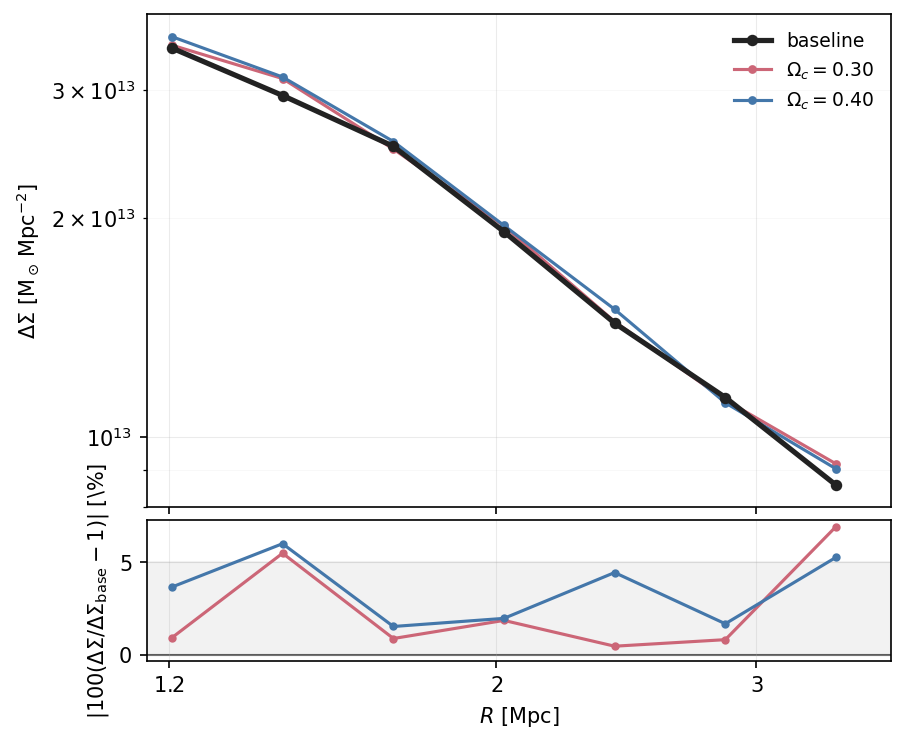

In [15]:
# ============================================================
# Plot stacked profiles + relative difference from baseline
# Paper-style version
# ============================================================

import numpy as np
import matplotlib.pyplot as plt


fig, (ax_top, ax_bot) = plt.subplots(
    2,
    1,
    figsize=(6.4, 5.6),
    dpi=150,
    sharex=True,
    gridspec_kw={"height_ratios": [3.5, 1], "hspace": 0.04},
)


baseline_label = "baseline"


# ============================================================
# Colors
# ============================================================

colors = {
    "baseline": "#222222",


    rf"$\Omega_c=0.30$": "#CC6677",  # muted red
    rf"$\Omega_c=0.40$": "#4477AA",  # muted blue
    "Omega_c=0.22_sigma8=0.90": "#228833",  # muted green
}


# ============================================================
# Baseline profile
# ============================================================

prof_base = ensembles[baseline_label].stacked_data

r_base = np.asarray(prof_base["radius"], dtype=float)

if "tangential_comp" in prof_base.colnames:
    ds_base = np.asarray(prof_base["tangential_comp"], dtype=float)
elif "gt" in prof_base.colnames:
    ds_base = np.asarray(prof_base["gt"], dtype=float)
else:
    raise ValueError(
        f"Could not find tangential profile column. Columns: {prof_base.colnames}"
    )


# ============================================================
# Plot profiles
# ============================================================

for label, ensemble in ensembles.items():
    print(label)
    prof = ensemble.stacked_data
    r = np.asarray(prof["radius"], dtype=float)

    if "tangential_comp" in prof.colnames:
        ds = np.asarray(prof["tangential_comp"], dtype=float)
    elif "gt" in prof.colnames:
        ds = np.asarray(prof["gt"], dtype=float)
    else:
        raise ValueError(
            f"Could not find tangential profile column. Columns: {prof.colnames}"
        )


    is_baseline = label == baseline_label

    if label in colors:
        color = colors[label]
    else:
        color = plt.cm.tab10(list(ensembles.keys()).index(label))


    # --------------------------------------------------------
    # Main profile
    # --------------------------------------------------------

    ax_top.plot(
        r,
        ds,
        marker="o",
        color=color,
        lw=2.5 if is_baseline else 1.5,
        ms=4.5 if is_baseline else 3.2,
        label=label,
        zorder=5 if is_baseline else 3,
    )


    # --------------------------------------------------------
    # Residual
    # --------------------------------------------------------

    if not is_baseline:

        if np.allclose(r, r_base):
            ds_base_here = ds_base
        else:
            ds_base_here = np.interp(r, r_base, ds_base)


        # Signed difference
        rel = np.abs(100.0 * (ds / ds_base_here - 1.0))


        ax_bot.plot(
            r,
            rel,
            marker="o",
            color=color,
            lw=1.5,
            ms=3,
            label=label,
            zorder=3,
        )


# ============================================================
# Formatting
# ============================================================

ax_top.set_xscale("log")
ax_top.set_yscale("log")

ax_top.set_ylabel(
    r"$\Delta\Sigma\ [{\rm M_\odot\,Mpc^{-2}}]$",
    fontsize=10,
)

ax_top.legend(
    fontsize=9,
    frameon=False,
    loc="best",
)


# ------------------------------------------------------------
# Bottom panel
# ------------------------------------------------------------

ax_bot.axhline(
    0,
    color="black",
    lw=1,
    alpha=0.6,
    zorder=1,
)


# 5% reference band
ax_bot.axhspan(
    0,
    5,
    color="gray",
    alpha=0.1,
    zorder=0,
)


ax_bot.set_xscale("log")

ax_bot.set_xlabel(
    r"$R\ [{\rm Mpc}]$",
    fontsize=10,
)

ax_bot.set_ylabel(
    r"$|100(\Delta\Sigma/\Delta\Sigma_{\rm base}-1)|$ [\%]",
    fontsize=10,
)


# ============================================================
# Grid and ticks
# ============================================================

for ax in (ax_top, ax_bot):

    ax.grid(
        which="major",
        alpha=0.25,
        lw=0.5,
    )

    ax.grid(
        which="minor",
        alpha=0.1,
        lw=0.4,
    )

    ax.tick_params(
        axis="both",
        which="both",
        labelsize=10,
    )


ax_bot.set_xlim(1.16, 3.7)

ax_bot.set_xticks(
    [1.2, 2.0, 3.0]
)

ax_bot.set_xticklabels(
    [r"$1.2$", r"$2$", r"$3$"]
)


# ============================================================
# Save
# ============================================================

plt.tight_layout()

fig.savefig(
    "../figures/delta_sigma_cosmo_comparison.pdf",
    bbox_inches="tight",
    pad_inches=0.03,
    dpi=300,
)

plt.show()